<a href="https://colab.research.google.com/github/topa1980/Hometasks/blob/main/Hometasks/ML_PTCourse_MicroHT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Микро-ДЗ 1: Знакомство с машинным обучением

## Описание задачи и загрузка данных

В этом задании вам нужно обучить линейную регрессию для предсказания стоимости домов в Калифорнии.

Альтернативная задача: прогноз стоимости алмазов.

Рекомендуем решать ее после выполнения этого ноутбука. Предоставим только данные, а пайплайн надо будет воспроизвести самостоятельно.

[Ссылка на данные.](https://raw.githubusercontent.com/aiedu-courses/stepik_eda_and_dev_tools/main/datasets/diamonds_good.csv)

Загружаем необходимые библиотеки.

In [4]:
import pandas as pd
import seaborn as sb
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_california_housing

Фиксируем `random_state` для воспроизводимости случайных значений.

In [5]:
RANDOM_STATE = 42

Загрузим данные и сформируем из них матрицу объект-признак `X` и вектор `y`, содержащий целевую переменную.

In [79]:
Data = fetch_california_housing(as_frame=True)

X = Data['data']
y = Data['target']

Посмотрим первые пять записей набора данных.

In [145]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Задание 1

 Сколько строк и столбцов в матрице `X`?

In [157]:
print(f"Количество строк {len(X)}, \nколичество столбцов {len(X.columns)}")

Количество строк 20640, 
количество столбцов 8


Посмотрим на зависимость стоимости домов (целевой переменной `y`) от признака `MedInc` (`Median Income`).
Для этого можно нарисовать диаграмму рассеяния.

Text(0, 0.5, 'House Price')

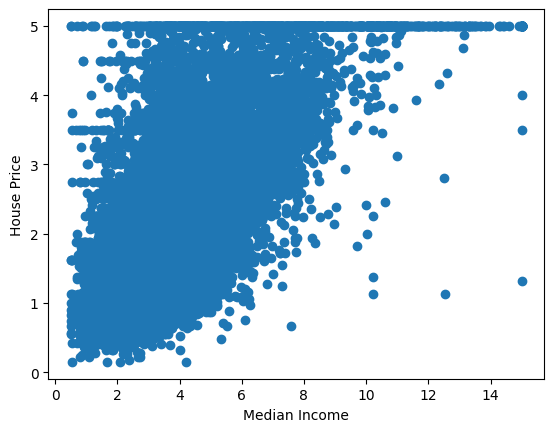

In [10]:
plt.scatter(X['MedInc'], y)
plt.xlabel('Median Income')
plt.ylabel('House Price')

По диаграмме видно, что чем больше `Median Income`, тем больше `House Price`, то есть видна прямая зависимость целевой переменной от признака `MedInc`.

## Задание 2

Постройте диаграмму рассеяния, отображающую зависимость целевой переменной от признака `Latitude`.
Какая это зависимость?

Text(0, 0.5, 'House Price')

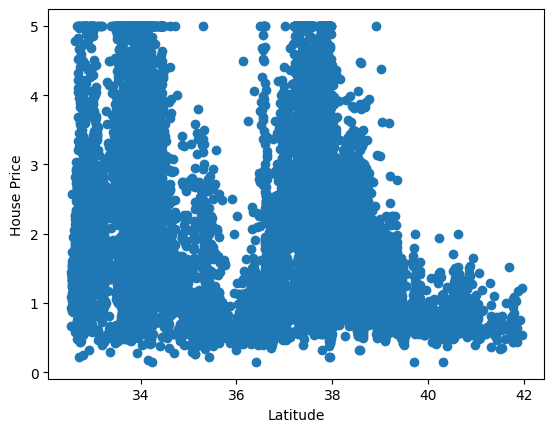

In [13]:
plt.scatter(X['Latitude'], y)
plt.xlabel('Latitude')
plt.ylabel('House Price')

Зависимость не прямая, есть несколько локальных максимума

Ещё немного поисследуем данные. Полноценный разведочный анализ в рамках этого задания, конечно, не провести, но какие-то инструменты мы потрогаем.

Давайте построим тепловую карту корреляций.

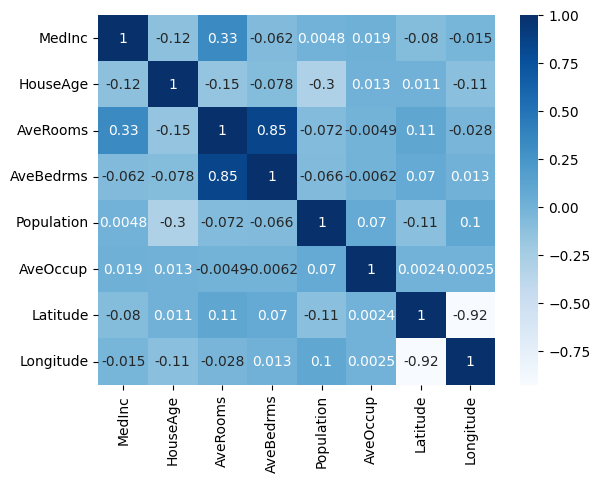

In [14]:
corr = X.corr()
sb.heatmap(corr, cmap="Blues", annot=True);

По этой матрице корреляций видно, что два наиболее зависимых признака - это `AveRooms` и `AveBedrms`.

Но интереснее посмотреть, какой признак имеет наибольшую корреляцию с целевой переменной!

## Задание 3

Добавьте к матрице `X` столбец `y` и постройте матрицу корреляций.
Какой признак имеет наибольшую по модулю корреляцию с таргетом?
После выполнения задания удалите добавленный столбец `y` из матрицы `X`.

Признак с наибольшей по модулю корреляцией с таргетом: MedInc
Значение корреляции: 0.688


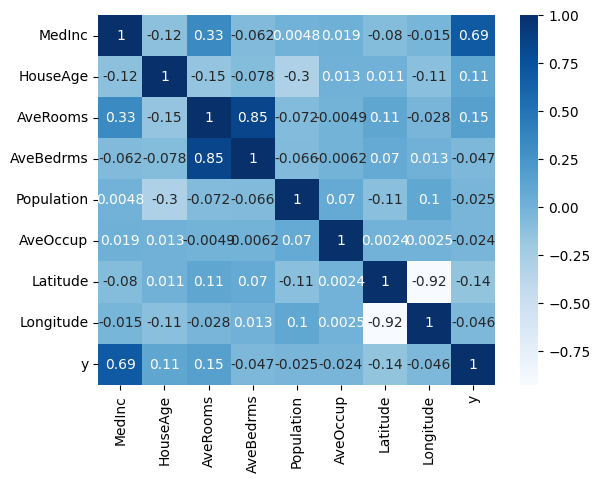

In [109]:
X.insert(loc= len(X.columns), column= "y", value= y)

corr = X.corr()

target_correlations = corr['y'].drop('y')
most_correlated_feature = target_correlations.abs().idxmax()
max_correlation_value = target_correlations.loc[most_correlated_feature]

print(f"Признак с наибольшей по модулю корреляцией с таргетом: {most_correlated_feature}")
print(f"Значение корреляции: {max_correlation_value:.3f}")

sb.heatmap(corr, cmap="Blues", annot=True)
#plt.show()

X = X.drop(labels="y", axis=1)

Разбейте данные на тренировочную и тестовую часть (в тест отправьте 25% данных).

In [160]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Тренировочные данные {Xtrain.shape=}")
print(f"Тестовые данные {Xtest.shape=} ")
print(f"Тестовых данных { len(Xtest) / ( len(Xtrain) + len(Xtest) )*100 }%")

Тренировочные данные Xtrain.shape=(15480, 8)
Тестовые данные Xtest.shape=(5160, 8) 
Тестовых данных 25.0%


##Задание 4

Сколько объектов попали в тест?

Обучите линейную регрессию с параметрами по умолчанию на тренировочных данных и сделайте предсказание на тестовых данных.

In [146]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(Xtrain, ytrain)

model.score(X, y), model.coef_

(0.6051997816358465,
 array([ 4.47600069e-01,  9.56752596e-03, -1.24755956e-01,  7.94471254e-01,
        -1.43902596e-06, -3.44307993e-03, -4.18555257e-01, -4.33405135e-01]))

In [161]:
from sklearn.metrics import mean_squared_error, r2_score

pred = model.predict(Xtest)

for i in range(10):
  print(f"{i}| Предсказание: {pred[i]:.2f}\t| Факт: {ytest.values[i]:.02f} | Разница: { (pred[i] - ytest.values[i]):.02f}" )


0| Предсказание: 0.72	| Факт: 0.48 | Разница: 0.25
1| Предсказание: 1.77	| Факт: 0.46 | Разница: 1.31
2| Предсказание: 2.71	| Факт: 5.00 | Разница: -2.29
3| Предсказание: 2.84	| Факт: 2.19 | Разница: 0.65
4| Предсказание: 2.60	| Факт: 2.78 | Разница: -0.18
5| Предсказание: 2.01	| Факт: 1.59 | Разница: 0.42
6| Предсказание: 2.64	| Факт: 1.98 | Разница: 0.66
7| Предсказание: 2.17	| Факт: 1.57 | Разница: 0.59
8| Предсказание: 2.75	| Факт: 3.40 | Разница: -0.65
9| Предсказание: 3.90	| Факт: 4.47 | Разница: -0.56


## Задание 5

Вычислите значение метрик *MSE* и *RMSE* на тестовых данных.
Ответ округлите до десятых.

In [ ]:
from sklearn.metrics import mean_squared_error

# ваш код здесь



print()